In [1]:
import mne
import os
import numpy as np
import pandas as pd
import scipy.io
from scipy.signal import butter, filtfilt, welch, windows
from scipy import signal
import matplotlib.pyplot as plt

### Sampling frequency

In [2]:
fs = 512
signal_strength = 0.85
band = 'delta'
#delta: 0.1-4
#theta: 4-7
#alpha 8-12
cluster = 5
start = 1
end = 5

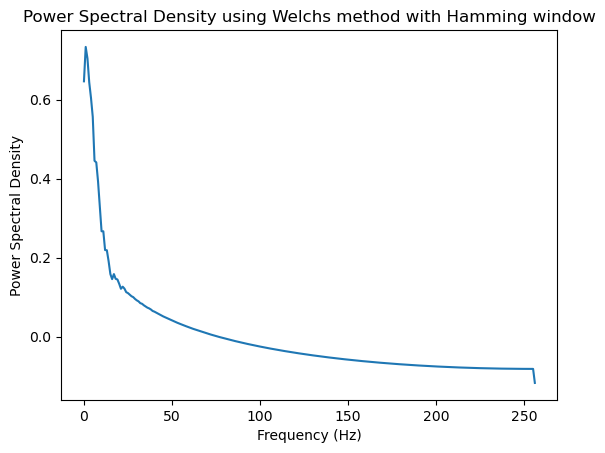

0
1
2
3
4


In [3]:
csz_folder = 'E:/sayan_24/GNN_aniket/CSZ_select_' + band + '_cluster_' + str(cluster) + '/'

df_csz = scipy.io.loadmat(csz_folder + 'train_csz1.mat')
df_test = scipy.io.loadmat(csz_folder + 'test1.mat')
df_he = scipy.io.loadmat(csz_folder+ 'train_he_full.mat')

df_csz = df_csz['train']
df_test = df_test['test']
df_he = df_he['train']

window = windows.hamming(512)
for batch in df_csz:
    for chnl in batch.T:
        f, Ypp = signal.welch(chnl, fs = fs, window=window, noverlap=fs/2)
        #print(Ypp)
        Pxx = 10*np.log10(Ypp)
        Pxx = (Pxx - np.mean(Pxx))/(np.max(Pxx) - np.min(Pxx))*signal_strength
        plt.plot(f, Pxx)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power Spectral Density')
        plt.title('Power Spectral Density using Welchs method with Hamming window')
        plt.show()
        for i in range(len(Pxx)):
            if(Ypp[i] > 1e-4):
                print(i)

        break
    break

### CSZ Data

In [4]:
csz_folder = 'E:/sayan_24/GNN_aniket/CSZ_select_' + band + '_cluster_' + str(cluster) + '/'
save_dir = 'E:/sayan_24/GNN_aniket/CSZ_PSD_data_' + band + '_cluster_' + str(cluster) + '/'
os.makedirs(save_dir, exist_ok = True)

df_he = scipy.io.loadmat(csz_folder+ 'train_he_full.mat')
df_he = df_he['train']

window = windows.hamming(512)

for case in range(1, 24):
    
    df_csz = scipy.io.loadmat(csz_folder + f'train_csz{case}.mat')
    df_test = scipy.io.loadmat(csz_folder + f'test{case}.mat')
    df_csz = df_csz['train']
    df_test = df_test['test']
    
    batches = []
    for batch in df_csz:
        channel = []
        for chnl in batch.T:
            f, Ypp = signal.welch(chnl, fs = fs, window=window, noverlap=fs/2)
            Pxx = 10*np.log10(Ypp)
            Pxx = (Pxx - np.mean(Pxx))/(np.max(Pxx) - np.min(Pxx))*signal_strength
            channel.append(Pxx[start:end].astype('float64'))
        batches.append(channel)

    # Save csz_corr_mat as .mat file
    save_path = os.path.join(save_dir, f'csz_PSD{case}.mat')
    scipy.io.savemat(save_path, {'csz_PSD': batches})

    batches = []
    for batch in df_test:
        channel = []
        for chnl in batch.T:
            f, Ypp = signal.welch(chnl, fs = fs, window=window, noverlap=fs/2)
            Pxx = 10*np.log10(Ypp)
            Pxx = (Pxx - np.mean(Pxx))/(np.max(Pxx) - np.min(Pxx))*signal_strength
            channel.append(Pxx[start:end].astype('float64'))
        batches.append(channel)

    # Save csz_corr_mat as .mat file
    save_path = os.path.join(save_dir, f'test_PSD{case}.mat')
    scipy.io.savemat(save_path, {'test_PSD': batches})

    batches = []
    for batch in df_he:
        channel = []
        for chnl in batch.T:
            f, Ypp = signal.welch(chnl, fs = fs, window=window, noverlap=fs/2)
            Pxx = 10*np.log10(Ypp)
            Pxx = (Pxx - np.mean(Pxx))/(np.max(Pxx) - np.min(Pxx))
            channel.append(Pxx[start:end].astype('float64'))
        batches.append(channel)

    # Save csz_corr_mat as .mat file
    save_path = os.path.join(save_dir, f'he_PSD{case}.mat')
    scipy.io.savemat(save_path, {'he_PSD': batches})

### HE data

In [5]:
he_folder = 'E:/sayan_24/GNN_aniket/HE_select_' + band + '_cluster_' + str(cluster) + '/'
save_dir = 'E:/sayan_24/GNN_aniket/HE_PSD_data_' + band + '_cluster_' + str(cluster) + '/'
os.makedirs(save_dir, exist_ok = True)

df_csz = scipy.io.loadmat(he_folder+ 'train_csz_full.mat')
df_csz = df_csz['train']

window = windows.hamming(512)

for case in range(1, 41):

    df_he = scipy.io.loadmat(he_folder + f'train_he{case}.mat')
    df_test = scipy.io.loadmat(he_folder + f'test{case}.mat')
    
    df_he = df_he['train']
    df_test = df_test['test']

    batches = []
    for batch in df_csz:
        channel = []
        for chnl in batch.T:
            f, Ypp = signal.welch(chnl, fs = fs, window=window, noverlap=fs/2)
            Pxx = 10*np.log10(Ypp)
            Pxx = (Pxx - np.mean(Pxx))/(np.max(Pxx) - np.min(Pxx))*signal_strength
            channel.append(Pxx[start:end].astype('float64'))
        batches.append(channel)
        
    # Save csz_corr_mat as .mat file
    save_path = os.path.join(save_dir, f'csz_PSD{case}.mat')
    scipy.io.savemat(save_path, {'csz_PSD': batches})

    batches = []
    for batch in df_test:
        channel = []
        for chnl in batch.T:
            f, Ypp = signal.welch(chnl, fs = fs, window=window, noverlap=fs/2)
            Pxx = 10*np.log10(Ypp)
            Pxx = (Pxx - np.mean(Pxx))/(np.max(Pxx) - np.min(Pxx))
            channel.append(Pxx[start:end].astype('float64'))
        batches.append(channel)

    # Save csz_corr_mat as .mat file
    save_path = os.path.join(save_dir, f'test_PSD{case}.mat')
    scipy.io.savemat(save_path, {'test_PSD': batches})

    batches = []
    for batch in df_he:
        channel = []
        for chnl in batch.T:
            f, Ypp = signal.welch(chnl, fs = fs, window=window, noverlap=fs/2)
            Pxx = 10*np.log10(Ypp)
            Pxx = (Pxx - np.mean(Pxx))/(np.max(Pxx) - np.min(Pxx))
            channel.append(Pxx[start:end].astype('float64'))
        batches.append(channel)

    # Save csz_corr_mat as .mat file
    save_path = os.path.join(save_dir, f'he_PSD{case}.mat')
    scipy.io.savemat(save_path, {'he_PSD': batches})